In [1]:
import pandas as pd


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Unemployment in India.csv")

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.shape

(768, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [7]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.shape

(740, 7)

In [10]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [11]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [12]:
df['Region'].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str

In [13]:
df['Region'].nunique()

28

In [15]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [16]:
df.columns.tolist()

['Region',
 ' Date',
 ' Frequency',
 ' Estimated Unemployment Rate (%)',
 ' Estimated Employed',
 ' Estimated Labour Participation Rate (%)',
 'Area']

In [17]:
df.columns = df.columns.str.strip()

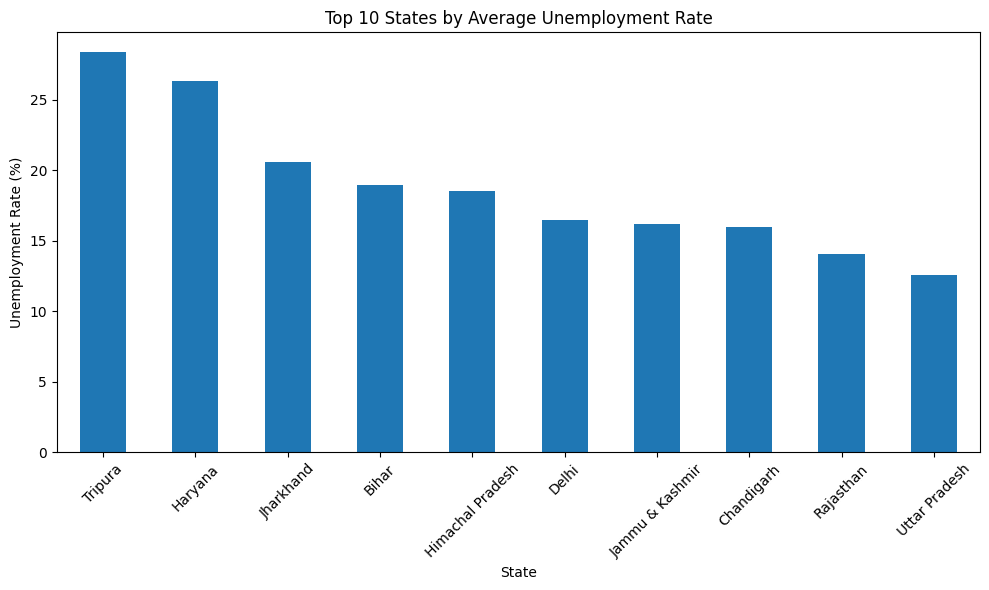

In [19]:
import matplotlib.pyplot as plt

top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

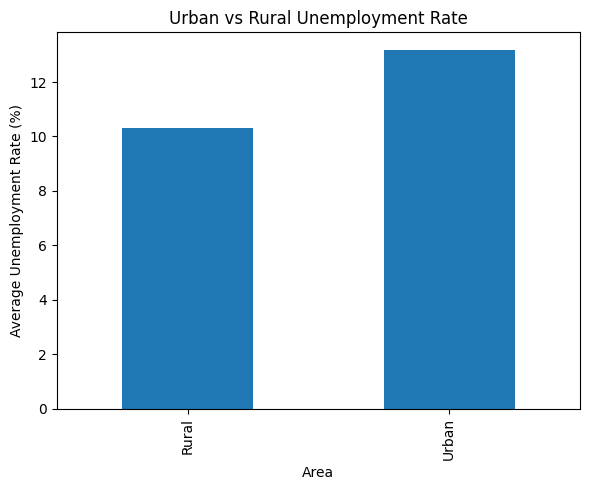

In [20]:
area_unemployment = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
area_unemployment.plot(kind='bar')
plt.title('Urban vs Rural Unemployment Rate')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

C:\Users\Vishal B\AppData\Local\Temp\ipykernel_4132\607996714.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


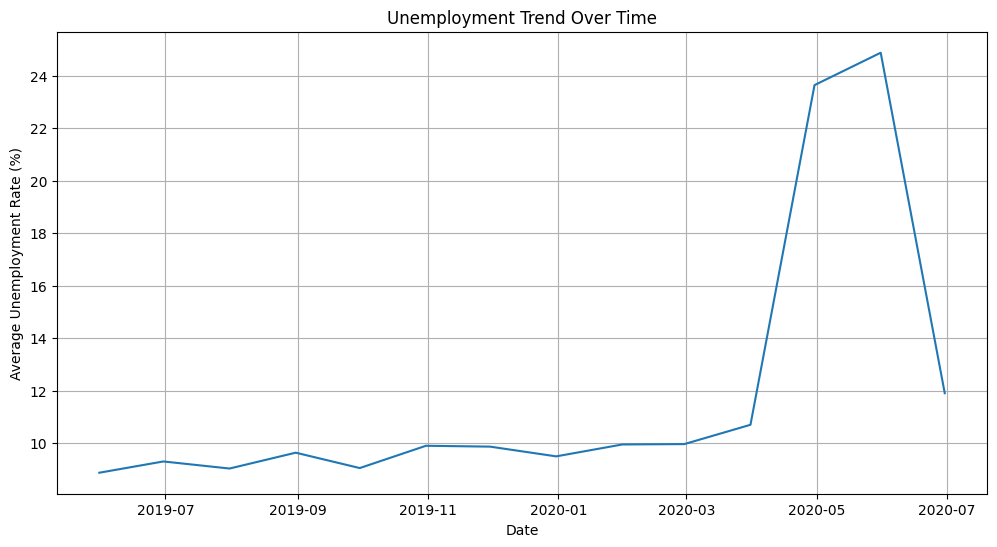

In [21]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_unemployment.index,
         monthly_unemployment.values)

plt.title('Unemployment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)
plt.show()

In [22]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

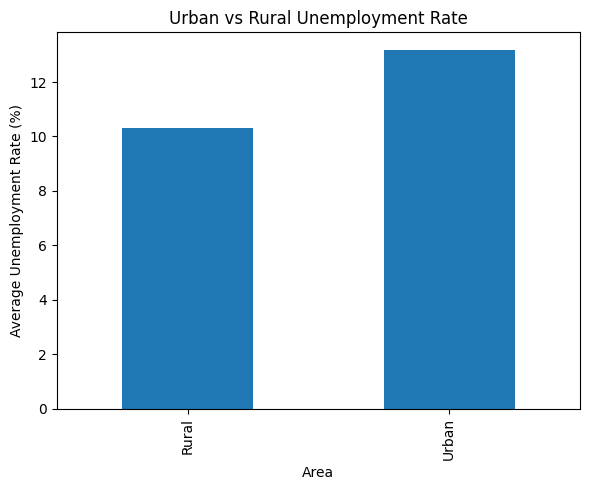

In [23]:
area_unemployment = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6,5))
area_unemployment.plot(kind='bar')

plt.title('Urban vs Rural Unemployment Rate')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

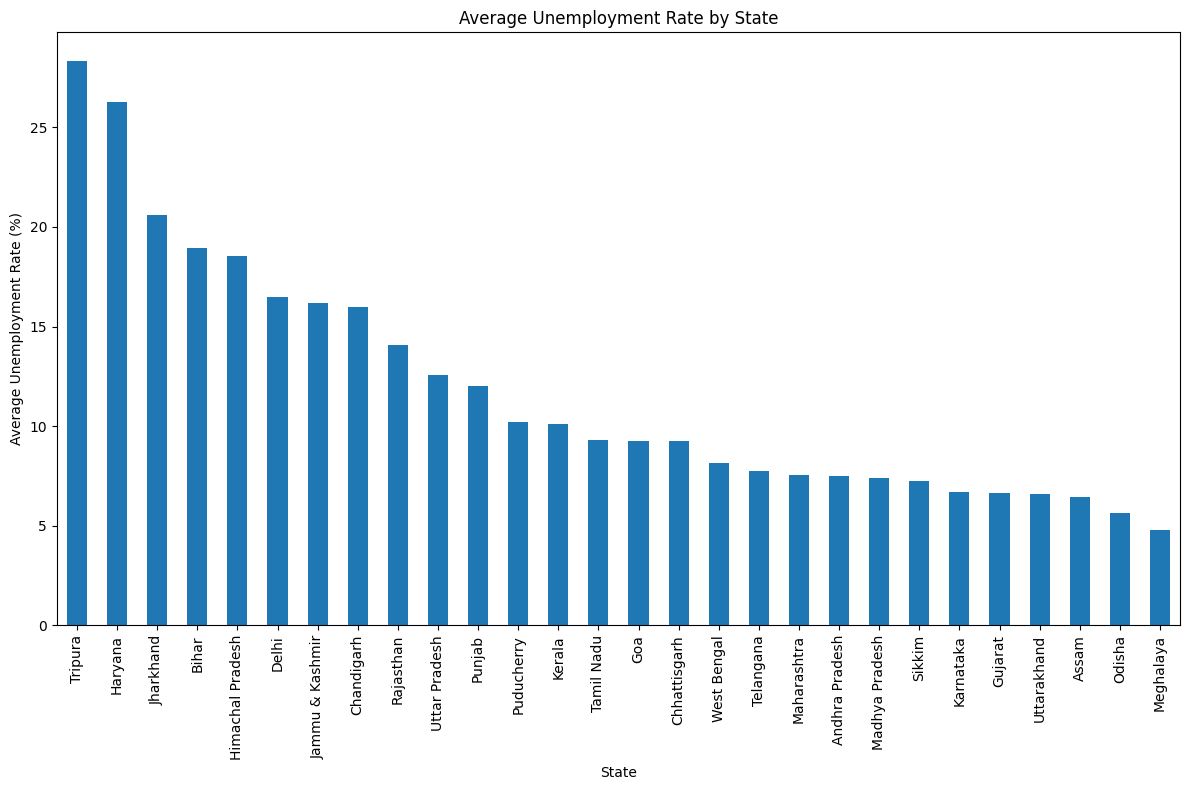

In [24]:
state_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))
state_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by State')
plt.xlabel('State')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Key Findings

1. The dataset contains unemployment statistics from 28 regions of India.

2. After data cleaning, 740 valid records were available for analysis.

3. The average unemployment rate was approximately 11.79%.

4. Tripura, Haryana, Jharkhand, Bihar and Himachal Pradesh showed relatively higher unemployment rates.

5. Meghalaya, Odisha and Assam showed comparatively lower unemployment rates.

6. A major spike in unemployment occurred during April-May 2020, corresponding to the COVID-19 lockdown period.

7. Significant differences were observed between urban and rural unemployment levels.

8. State-wise analysis revealed notable regional variations in unemployment patterns.

# Conclusion

This project analyzed unemployment trends across India using Python and data visualization techniques.

The analysis revealed significant regional differences in unemployment rates and highlighted the severe impact of the COVID-19 pandemic on employment. The unemployment rate increased sharply during the lockdown period and gradually declined afterward.

Through data cleaning, exploratory data analysis and visualization, meaningful insights were obtained regarding unemployment patterns across states and regions of India.

This study demonstrates how data science techniques can be used to understand socio-economic challenges and support informed decision-making.

In [28]:
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

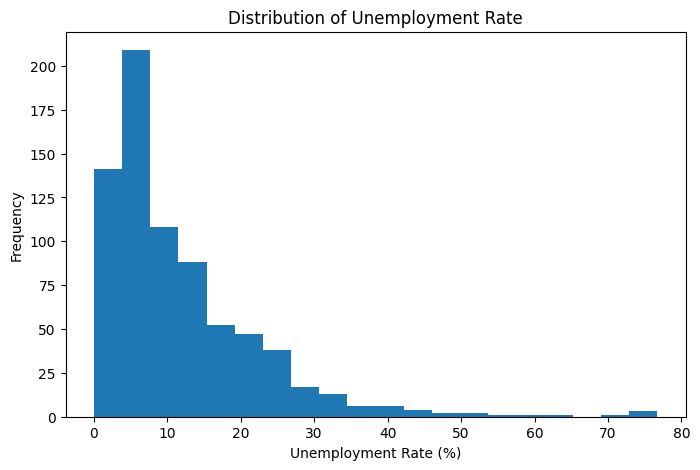

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df['Estimated Unemployment Rate (%)'], bins=20)
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()

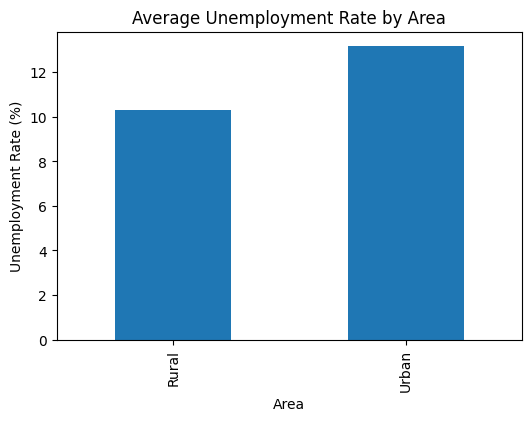

In [31]:
avg_area = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6,4))
avg_area.plot(kind='bar')
plt.title('Average Unemployment Rate by Area')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')
plt.show()